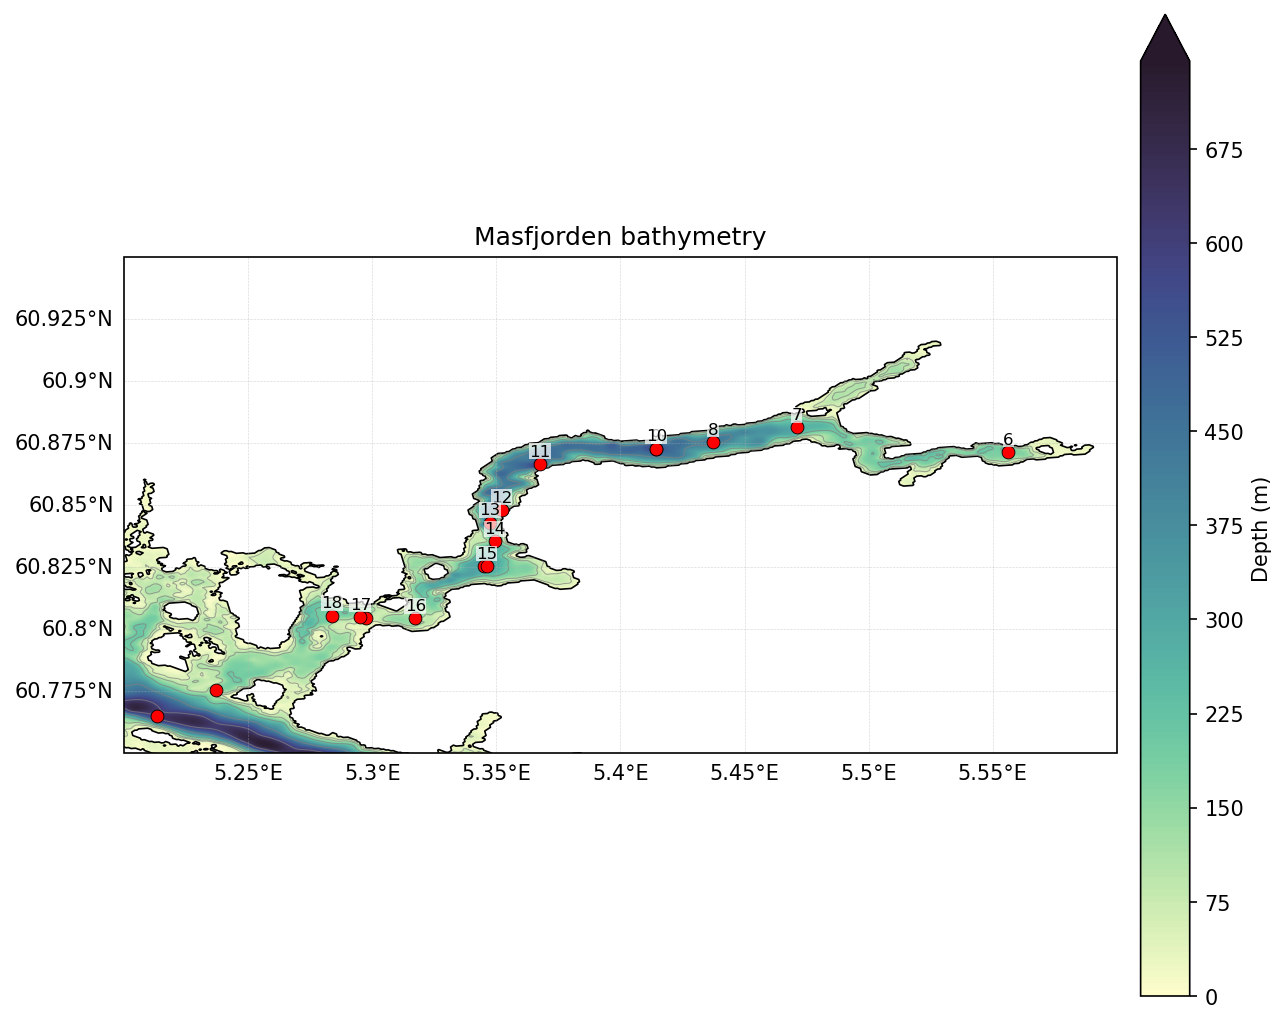

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean


# load npy

data = np.load(r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\highres_bathy.npy")

lat2 = data[0,:,:]
lon2 = data[1,:,:]
depth2 = data[2,:,:]

ds = xr.open_dataset(r"C:\Users\quzho2904\Downloads\HB2026009004.nc")

ctd_lon = ds["lon"].values
ctd_lat = ds["lat"].values
sta = ds["sta"].values


# process depth

depth2 = np.array(depth2, dtype=float)

# mask land or invalid values
depth2[depth2 <= 0] = np.nan

# used for plotting coastline
elev2 = np.where(np.isnan(depth2), 1, -1)

# specify plotting range

lon_min = 4.7
lon_max = 5.6
lat_min = 60.25
lat_max = 60.95


# plot

fig = plt.figure(figsize=(9,8), dpi=150)

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

# bathymetry
levels = np.arange(0, 750, 5)

cf = ax.contourf(
    lon2,
    lat2,
    depth2,
    levels=levels,
    cmap=cmocean.cm.deep,
    extend="max",
    transform=ccrs.PlateCarree(),
    zorder=1
)

# coastline
ax.contour(
    lon2,
    lat2,
    elev2,
    levels=[0],
    colors="black",
    linewidths=0.8,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# isobaths (depth contours)
ax.contour(
    lon2,
    lat2,
    depth2,
    levels=[50, 100, 200, 400, 600],
    colors="gray",
    linewidths=0.5,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# CTD stations
ax.scatter(
    ctd_lon,
    ctd_lat,
    s=38,
    color="red",
    edgecolor="black",
    linewidth=0.4,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# label only stations 6–18
for x, y, s in zip(ctd_lon, ctd_lat, sta):

    s_int = int(s)

    if 6 <= s_int <= 18:

        ax.text(
            x,
            y + 0.002,
            str(s_int),
            fontsize=8,
            color="black",
            ha="center",
            va="bottom",
            transform=ccrs.PlateCarree(),
            zorder=4,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.7,
                pad=0.15
            )
        )
    

# grid
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

# colorbar
cbar = plt.colorbar(cf, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("Depth (m)")

plt.title("Bathymetry")

plt.tight_layout()
plt.show()